In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.ops import unary_union
 
# --- Paths ---
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
CMIP6_DIR     = os.path.join(BASE_DIR, "data", "raw", "CMIP6")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

In [2]:
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))

def weighted_mean(ds):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds["ph"].weighted(weights).mean(
        dim=["latitude","longitude"], skipna=True)

ph_mean_BBI  = weighted_mean(ds_BBI)
ph_mean_BBII = weighted_mean(ds_BBII)

# Promedio de ambas zonas
ph_combined = (ph_mean_BBI + ph_mean_BBII) / 2
df_obs = ph_combined.to_dataframe(name="pH").reset_index()
df_obs["time"] = pd.to_datetime(df_obs["time"])

ph_obs_2020 = df_obs[df_obs["time"].dt.year == 2020]["pH"].mean()
print(f"pH BB 2020 CMEMS: {ph_obs_2020:.4f}")

pH BB 2020 CMEMS: 8.0514


In [3]:
ds_245 = xr.open_dataset(os.path.join(CMIP6_DIR, "pHT_median_ssp245.nc"))

lat2d = ds_245["latitude"].values
lon2d = ds_245["longitude"].values
ph2d  = ds_245["pHT"].values  # (9, 180, 360)

# Máscara del BB
mask_bb = (
    (lat2d >= -56) & (lat2d <= -52) &
    (lon2d >= -64) & (lon2d <= -54)
)

ph_bb_2020_cmip6 = ph2d[0][mask_bb].mean()
print(f"pH BB 2020 CMIP6 SSP2-4.5: {ph_bb_2020_cmip6:.4f}")
print(f"pH BB 2020 CMEMS          : {ph_obs_2020:.4f}")
print(f"Bias (CMIP6 - CMEMS)      : {ph_bb_2020_cmip6 - ph_obs_2020:.4f}")

pH BB 2020 CMIP6 SSP2-4.5: nan
pH BB 2020 CMEMS          : 8.0514
Bias (CMIP6 - CMEMS)      : nan


C:\Users\gisel\AppData\Local\Temp\ipykernel_171424\4255156097.py:13: RuntimeWarning: Mean of empty slice.
  ph_bb_2020_cmip6 = ph2d[0][mask_bb].mean()
C:\Users\gisel\anaconda3\envs\BB_stress_paper\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
print(f"lat rango: {lat2d.min():.2f} → {lat2d.max():.2f}")
print(f"lon rango: {lon2d.min():.2f} → {lon2d.max():.2f}")

lat rango: -89.50 → 89.50
lon rango: 20.50 → 379.50


In [5]:
# Convertir longitudes del BB a convención 0-360
lon_min = -64 + 360  # = 296
lon_max = -54 + 360  # = 306

mask_bb = (
    (lat2d >= -56) & (lat2d <= -52) &
    (lon2d >= lon_min) & (lon2d <= lon_max)
)

print(f"Píxeles en el BB: {mask_bb.sum()}")
ph_bb_2020_cmip6 = ph2d[0][mask_bb].mean()
print(f"pH BB 2020 CMIP6 SSP2-4.5: {ph_bb_2020_cmip6:.4f}")
print(f"pH BB 2020 CMEMS          : {ph_obs_2020:.4f}")
print(f"Bias (CMIP6 - CMEMS)      : {ph_bb_2020_cmip6 - ph_obs_2020:.4f}")

Píxeles en el BB: 40
pH BB 2020 CMIP6 SSP2-4.5: nan
pH BB 2020 CMEMS          : 8.0514
Bias (CMIP6 - CMEMS)      : nan


In [6]:
# Ver cuántos NaN hay en esos píxeles
ph_bb_vals = ph2d[0][mask_bb]
print(f"Valores en el BB: {ph_bb_vals}")
print(f"NaN: {np.isnan(ph_bb_vals).sum()} de {len(ph_bb_vals)}")

# Ver todos los timesteps
for i, year in enumerate([2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]):
    vals  = ph2d[i][mask_bb]
    valid = vals[~np.isnan(vals)]
    mean  = f"{valid.mean():.4f}" if len(valid) > 0 else "NaN"
    print(f"{year}: {len(valid)} válidos, media={mean}")

Valores en el BB: [8.059 8.059 8.058 8.057 8.055 8.055 8.057 8.06  8.062 8.065 8.069 8.066
 8.062 8.057 8.053 8.051 8.053 8.057 8.06  8.062 8.077 8.074 8.07  8.063
 8.047 8.044 8.047 8.052 8.055 8.057 8.081 8.078 8.078 8.081   nan   nan
 8.045 8.05  8.052 8.054]
NaN: 2 de 40
2020: 38 válidos, media=8.0601
2030: 38 válidos, media=8.0342
2040: 38 válidos, media=8.0079
2050: 38 válidos, media=7.9817
2060: 38 válidos, media=7.9578
2070: 38 válidos, media=7.9403
2080: 38 válidos, media=7.9209
2090: 38 válidos, media=7.9142
2100: 38 válidos, media=7.9093


#### Analisis completo para el papaer

In [7]:
import os
import numpy as np
import pandas as pd
import xarray as xr
 
BASE_DIR  = os.path.abspath("..")
CMIP6_DIR = os.path.join(BASE_DIR, "data", "raw", "CMIP6")
 
# Longitudes del BB en convención 0-360
LON_MIN = -64 + 360  # 296
LON_MAX = -54 + 360  # 306
LAT_MIN = -56
LAT_MAX = -52
 
DECADAS = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]
 
# pH observado 2020 (ya calculado antes)
PH_OBS_2020    = 8.0514
AR_OBS_2020    = None  # completar después si querés bias de aragonita
CALC_OBS_2020  = None
PCO2_OBS_2020  = None

In [8]:
# =============================================================================
# Archivos por variable y escenario
# =============================================================================
 
FILES = {
    "pH": {
        "ssp245": ("pHT_median_ssp245.nc",    "pHT"),
        "ssp585": ("pHT_median_ssp585.nc",    "pHT"),
    },
    "Aragonite": {
        "ssp245": ("Aragonite_median_ssp245.nc", None),  # None = detectar automático
        "ssp585": ("Aragonite_median_ssp585.nc", None),
    },
    "Calcite": {
        "ssp245": ("Calcite_median_ssp245.nc",   None),
        "ssp585": ("Calcite_median_ssp585.nc",   None),
    },
    "pCO2": {
        "ssp245": ("pCO2_median_ssp245.nc",      None),
        "ssp585": ("pCO2_median_ssp585.nc",      None),
    },
}
 

In [9]:
# =============================================================================
# Función principal
# =============================================================================
 
def explore_cmip6(filename, varname=None):
    """
    Carga un archivo CMIP6, detecta la variable si no se especifica,
    y calcula el promedio del BB por década.
    """
    path = os.path.join(CMIP6_DIR, filename)
    ds   = xr.open_dataset(path)
 
    # Detectar nombre de variable automáticamente si no se especifica
    if varname is None:
        data_vars = [v for v in ds.data_vars
                     if v not in ["latitude", "longitude"]]
        varname = data_vars[0]
        print(f"  Variable detectada: {varname}")
 
    lat2d = ds["latitude"].values
    lon2d = ds["longitude"].values
    data  = ds[varname].values  # (9, 180, 360)
 
    # Máscara del BB
    mask_bb = (
        (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX) &
        (lon2d >= LON_MIN) & (lon2d <= LON_MAX)
    )
    print(f"  Píxeles en el BB: {mask_bb.sum()}")
 
    # Media por década
    results = []
    for i, year in enumerate(DECADAS):
        vals  = data[i][mask_bb]
        valid = vals[~np.isnan(vals)]
        mean  = float(np.nanmean(valid)) if len(valid) > 0 else np.nan
        std   = float(np.nanstd(valid))  if len(valid) > 0 else np.nan
        results.append({"year": year, "mean": mean, "std": std})
 
    df = pd.DataFrame(results)
    return df, varname
 

In [10]:
# =============================================================================
# Correr para todas las variables y escenarios
# =============================================================================
 
results_all = {}
 
for varname, scenarios in FILES.items():
    results_all[varname] = {}
    print(f"\n{'='*50}")
    print(f"VARIABLE: {varname}")
 
    for scenario, (filename, vname) in scenarios.items():
        print(f"\n  Escenario: {scenario}")
        df, detected_var = explore_cmip6(filename, vname)
        results_all[varname][scenario] = df
 
        print(f"  Proyección por década:")
        for _, row in df.iterrows():
            print(f"    {int(row['year'])}: {row['mean']:.4f} ± {row['std']:.4f}")


VARIABLE: pH

  Escenario: ssp245
  Píxeles en el BB: 40
  Proyección por década:
    2020: 8.0601 ± 0.0098
    2030: 8.0342 ± 0.0104
    2040: 8.0079 ± 0.0107
    2050: 7.9817 ± 0.0109
    2060: 7.9578 ± 0.0109
    2070: 7.9403 ± 0.0114
    2080: 7.9209 ± 0.0119
    2090: 7.9142 ± 0.0114
    2100: 7.9093 ± 0.0121

  Escenario: ssp585
  Píxeles en el BB: 40
  Proyección por década:
    2020: 8.0591 ± 0.0099
    2030: 8.0286 ± 0.0106
    2040: 7.9926 ± 0.0106
    2050: 7.9443 ± 0.0112
    2060: 7.8962 ± 0.0102
    2070: 7.8395 ± 0.0115
    2080: 7.7783 ± 0.0116
    2090: 7.7197 ± 0.0112
    2100: 7.6668 ± 0.0126

VARIABLE: Aragonite

  Escenario: ssp245
  Variable detectada: aragonite
  Píxeles en el BB: 40
  Proyección por década:
    2020: 1.7584 ± 0.0764
    2030: 1.6766 ± 0.0758
    2040: 1.5953 ± 0.0746
    2050: 1.5258 ± 0.0714
    2060: 1.4708 ± 0.0693
    2070: 1.4008 ± 0.0679
    2080: 1.3513 ± 0.0729
    2090: 1.3568 ± 0.0662
    2100: 1.3379 ± 0.0696

  Escenario: ssp585
  V

In [11]:
# =============================================================================
# Bias con CMEMS (solo para pH por ahora)
# =============================================================================
 
print(f"\n{'='*50}")
print("BIAS pH (CMIP6 2020 vs CMEMS 2020)")
for scenario in ["ssp245", "ssp585"]:
    ph_2020 = results_all["pH"][scenario].iloc[0]["mean"]
    bias    = ph_2020 - PH_OBS_2020
    print(f"  {scenario}: CMIP6={ph_2020:.4f}, CMEMS={PH_OBS_2020:.4f}, bias={bias:+.4f}")


BIAS pH (CMIP6 2020 vs CMEMS 2020)
  ssp245: CMIP6=8.0601, CMEMS=8.0514, bias=+0.0087
  ssp585: CMIP6=8.0591, CMEMS=8.0514, bias=+0.0077


In [12]:
# =============================================================================
# Guardar resultados como CSV para usar en la figura
# =============================================================================
 
OUT_DIR = os.path.join(BASE_DIR, "data", "processed", "CMIP6")
os.makedirs(OUT_DIR, exist_ok=True)
 
for varname, scenarios in results_all.items():
    for scenario, df in scenarios.items():
        df["variable"] = varname
        df["scenario"] = scenario
        fname = f"{varname}_{scenario}_BB_decadal.csv"
        df.to_csv(os.path.join(OUT_DIR, fname), index=False)
        print(f"✅ Guardado: {fname}")

✅ Guardado: pH_ssp245_BB_decadal.csv
✅ Guardado: pH_ssp585_BB_decadal.csv
✅ Guardado: Aragonite_ssp245_BB_decadal.csv
✅ Guardado: Aragonite_ssp585_BB_decadal.csv
✅ Guardado: Calcite_ssp245_BB_decadal.csv
✅ Guardado: Calcite_ssp585_BB_decadal.csv
✅ Guardado: pCO2_ssp245_BB_decadal.csv
✅ Guardado: pCO2_ssp585_BB_decadal.csv


### Figura 6

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
CMIP6_DIR     = os.path.join(BASE_DIR, "data", "processed", "CMIP6")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
 
plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

In [14]:
# =============================================================================
# Cargar proyecciones CMIP6
# =============================================================================
 
def load_cmip6(varname):
    df245 = pd.read_csv(os.path.join(CMIP6_DIR, f"{varname}_ssp245_BB_decadal.csv"))
    df585 = pd.read_csv(pd.read_csv(os.path.join(CMIP6_DIR, f"{varname}_ssp585_BB_decadal.csv")))
    return df245, df585
 
# Cargar también los std
def load_cmip6_with_std(varname):
    df245 = pd.read_csv(os.path.join(CMIP6_DIR, f"{varname}_ssp245_BB_decadal.csv"))
    df585 = pd.read_csv(os.path.join(CMIP6_DIR, f"{varname}_ssp585_BB_decadal.csv"))
    return df245, df585
 
ph245,  ph585  = load_cmip6_with_std("pH")
ar245,  ar585  = load_cmip6_with_std("Aragonite")
ca245,  ca585  = load_cmip6_with_std("Calcite")
co245,  co585  = load_cmip6_with_std("pCO2")

In [15]:
# =============================================================================
# Cargar serie histórica CMEMS
# =============================================================================
 
import xarray as xr
import geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union
 
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))
 
def weighted_mean(ds, var):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds[var].weighted(weights).mean(
        dim=["latitude","longitude"], skipna=True)
 
def get_annual_mean(ds, var):
    da = weighted_mean(ds, var)
    df = da.to_dataframe(name=var).reset_index()
    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year
    annual = df.groupby("year")[var].mean().reset_index()
    return annual
 
# Series anuales históricas
hist_ph   = (get_annual_mean(ds_BBI, "ph")["ph"]   + get_annual_mean(ds_BBII, "ph")["ph"])   / 2
hist_ar   = (get_annual_mean(ds_BBI, "omega_ar")["omega_ar"] + get_annual_mean(ds_BBII, "omega_ar")["omega_ar"]) / 2
hist_ca   = (get_annual_mean(ds_BBI, "omega_ca")["omega_ca"] + get_annual_mean(ds_BBII, "omega_ca")["omega_ca"]) / 2
hist_co   = (get_annual_mean(ds_BBI, "spco2")["spco2"]       + get_annual_mean(ds_BBII, "spco2")["spco2"])       / 2
hist_years = get_annual_mean(ds_BBI, "ph")["year"].values

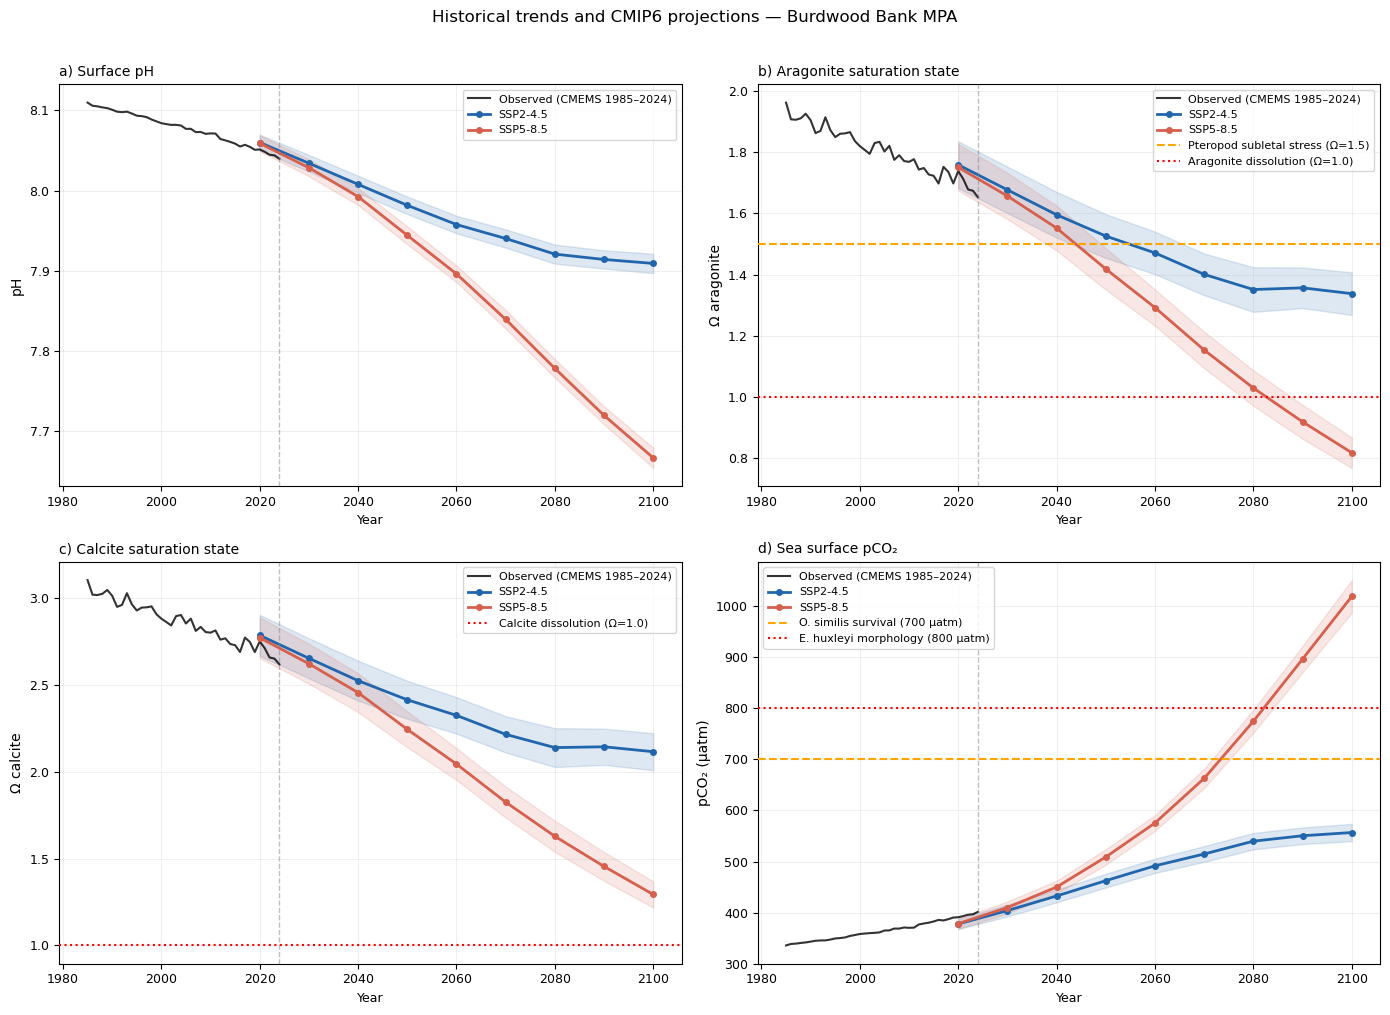

✅ Fig6_CMIP6_projections.png guardada


In [16]:
# =============================================================================
# Figura: 2x2 paneles
# =============================================================================
 
COLORS = {"ssp245": "#2166ac", "ssp585": "#d6604d", "hist": "black"}
 
PANELS = [
    {
        "letter"   : "a)",
        "title"    : "Surface pH",
        "hist"     : hist_ph,
        "df245"    : ph245,
        "df585"    : ph585,
        "thresholds": [],
        "ylabel"   : "pH",
    },
    {
        "letter"   : "b)",
        "title"    : "Aragonite saturation state",
        "hist"     : hist_ar,
        "df245"    : ar245,
        "df585"    : ar585,
        "thresholds": [
            (1.5, "orange", "--", "Pteropod subletal stress (Ω=1.5)"),
            (1.0, "red",    ":",  "Aragonite dissolution (Ω=1.0)"),
        ],
        "ylabel"   : "Ω aragonite",
    },
    {
        "letter"   : "c)",
        "title"    : "Calcite saturation state",
        "hist"     : hist_ca,
        "df245"    : ca245,
        "df585"    : ca585,
        "thresholds": [
            (1.0, "red", ":", "Calcite dissolution (Ω=1.0)"),
        ],
        "ylabel"   : "Ω calcite",
    },
    {
        "letter"   : "d)",
        "title"    : "Sea surface pCO₂",
        "hist"     : hist_co,
        "df245"    : co245,
        "df585"    : co585,
        "thresholds": [
            (700,  "orange", "--", "O. similis survival (700 µatm)"),
            (800,  "red",    ":",  "E. huxleyi morphology (800 µatm)"),
        ],
        "ylabel"   : "pCO₂ (µatm)",
    },
]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
 
for ax, panel in zip(axes, PANELS):
 
    # --- Serie histórica CMEMS ---
    ax.plot(hist_years, panel["hist"].values,
            color=COLORS["hist"], lw=1.5, alpha=0.8,
            label="Observed (CMEMS 1985–2024)")
 
    # --- Proyecciones CMIP6 ---
    for df, scenario, color, label in [
        (panel["df245"], "ssp245", COLORS["ssp245"], "SSP2-4.5"),
        (panel["df585"], "ssp585", COLORS["ssp585"], "SSP5-8.5"),
    ]:
        years = df["year"].values
        mean  = df["mean"].values
        std   = df["std"].values
 
        ax.plot(years, mean, color=color, lw=2,
                marker="o", markersize=4, label=label)
        ax.fill_between(years, mean - std, mean + std,
                        color=color, alpha=0.15)
 
    # --- Línea vertical: límite histórico/proyección ---
    ax.axvline(2024, color="gray", lw=1, linestyle="--", alpha=0.5)
 
    # --- Umbrales biológicos ---
    for val, color, ls, label in panel["thresholds"]:
        ax.axhline(val, color=color, lw=1.5,
                   linestyle=ls, label=label, zorder=3)
 
    ax.set_title(f"{panel['letter']} {panel['title']}",
                 fontsize=10, loc="left")
    ax.set_ylabel(panel["ylabel"], fontsize=10)
    ax.set_xlabel("Year", fontsize=9)
    ax.grid(alpha=0.2)
 
    if panel["letter"] == "a)":
        ax.legend(fontsize=8, loc="upper right")
    elif panel["letter"] == "d)":
        ax.legend(fontsize=8, loc="upper left")
    elif panel["thresholds"]:
        ax.legend(fontsize=8, loc="upper right")
 
plt.suptitle(
    "Historical trends and CMIP6 projections — Burdwood Bank MPA",
    fontsize=12, y=1.01
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig6_CMIP6_projections.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig6_CMIP6_projections.png guardada")
 

Aclaraciones para el paper: CMIP6 projections were spatially averaged over the Burdwood Bank domain using the same geographic boundaries as the observational analysis. The inter-model median was used as the central estimate, with the inter-model standard deviation as a measure of model uncertainty. A bias of +0.008 pH units was detected between the CMIP6 ensemble median and the CMEMS observational product for the reference decade 2020, which was considered negligible and no bias correction was applied. Historical and projected time series are presented jointly for visualization purposes; differences in temporal resolution (monthly vs. decadal) and spatial resolution (0.25° vs. 1°) between products should be considered when interpreting results

### agrupando decadal la serie historica

In [22]:
# Paleta global — daltónico-friendly (Wong 2011)
COLOR_BBI  = "#009E73"  # verde esmeralda
COLOR_BBII = "#E69F00"  # naranja dorado
COLOR_WARN = "#D55E00"  # naranja rojizo — alerta temprana
COLOR_CRIT = "#CC79A7"  # rosa/magenta  — umbral crítico
COLOR_PCO2 = "#0072B2"  # azul          — umbral pCO₂ E. huxleyi

In [17]:
import pandas as pd

def decadal_avg(hist_series, hist_years):
    """Agrupa la serie histórica mensual en promedios decadales."""
    df = pd.DataFrame({"year": hist_years, "value": hist_series})
    df["decade"] = (df["year"] // 10) * 10
    decadal = df.groupby("decade")["value"].mean().reset_index()
    # Usar el punto medio de cada década para graficar (ej: 1985-1989 -> 1987)
    decadal["year_mid"] = decadal["decade"] + 5
    return decadal

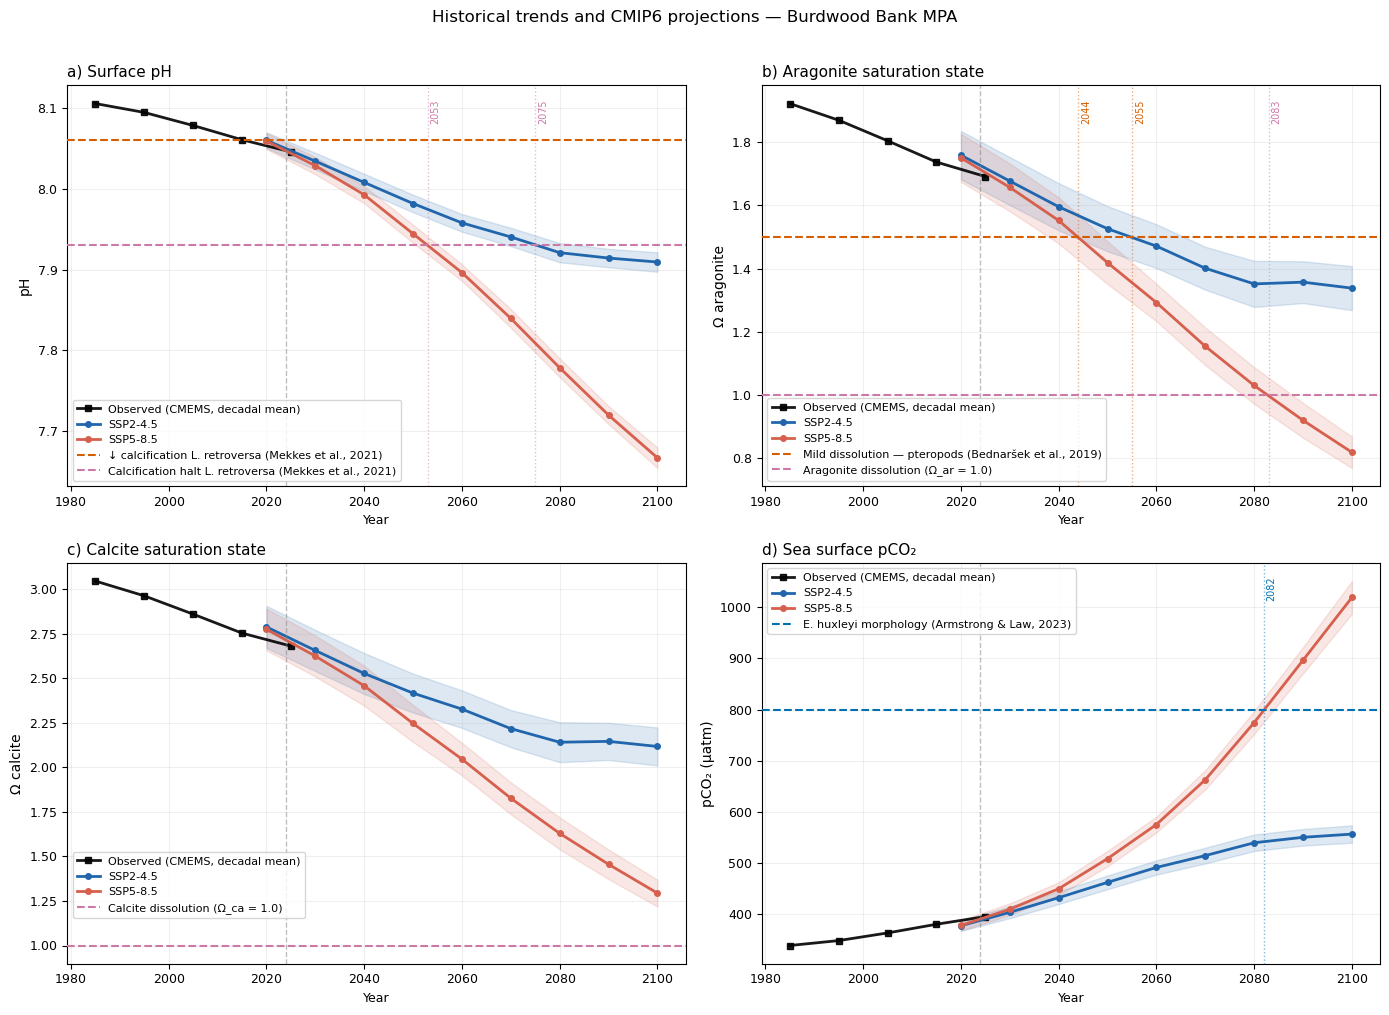

✅ Fig6_CMIP6_projections.png guardada


In [32]:
OLORS = {"ssp245": "#2166ac", "ssp585": "#d6604d", "hist": "black"}
 
PANELS = [
    {
        "letter"   : "a)",
        "title"    : "Surface pH",
        "hist"     : hist_ph,
        "df245"    : ph245,
        "df585"    : ph585,
        "thresholds": [
            (8.06, COLOR_WARN, "--", "↓ calcification L. retroversa (Mekkes et al., 2021)"),
            (7.93, COLOR_CRIT, "--", "Calcification halt L. retroversa (Mekkes et al., 2021)"),
        ],
        "ylabel"   : "pH",
    },
    {
        "letter"   : "b)",
        "title"    : "Aragonite saturation state",
        "hist"     : hist_ar,
        "df245"    : ar245,
        "df585"    : ar585,
        "thresholds": [
            (1.5, COLOR_WARN, "--", "Mild dissolution — pteropods (Bednaršek et al., 2019)"),
            (1.0, COLOR_CRIT, "--", "Aragonite dissolution (Ω_ar = 1.0)"),
        ],
        "ylabel"   : "Ω aragonite",
    },
    {
        "letter"   : "c)",
        "title"    : "Calcite saturation state",
        "hist"     : hist_ca,
        "df245"    : ca245,
        "df585"    : ca585,
        "thresholds": [
            (1.0, COLOR_CRIT, "--", "Calcite dissolution (Ω_ca = 1.0)"),
        ],
        "ylabel"   : "Ω calcite",
    },
    {
        "letter"   : "d)",
        "title"    : "Sea surface pCO₂",
        "hist"     : hist_co,
        "df245"    : co245,
        "df585"    : co585,
        "thresholds": [
            (800, COLOR_PCO2, "--", "E. huxleyi morphology (Armstrong & Law, 2023)"),
        ],
        "ylabel"   : "pCO₂ (µatm)",
    },
]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
 
for ax, panel in zip(axes, PANELS):
 
    # --- Serie histórica CMEMS (promedio decadal) ---
    hist_dec = decadal_avg(panel["hist"].values, hist_years)
    ax.plot(hist_dec["year_mid"], hist_dec["value"],
        color=COLORS["hist"], lw=2, marker="s", markersize=5,
        alpha=0.9, label="Observed (CMEMS, decadal mean)")
 
    # --- Proyecciones CMIP6 ---
    for df, scenario, color, label in [
        (panel["df245"], "ssp245", COLORS["ssp245"], "SSP2-4.5"),
        (panel["df585"], "ssp585", COLORS["ssp585"], "SSP5-8.5"),
    ]:
        years = df["year"].values
        mean  = df["mean"].values
        std   = df["std"].values
 
        ax.plot(years, mean, color=color, lw=2,
                marker="o", markersize=4, label=label)
        ax.fill_between(years, mean - std, mean + std,
                        color=color, alpha=0.15)
 
    # --- Línea vertical: límite histórico/proyección ---
    ax.axvline(2024, color="gray", lw=1, linestyle="--", alpha=0.5)
 
    # --- Umbrales biológicos ---
    for val, color, ls, label in panel["thresholds"]:
        ax.axhline(val, color=color, lw=1.5,
                   linestyle=ls, label=label, zorder=3)
        
   # --- Marcar años de cruce de umbrales (líneas verticales finas + texto) ---
    crossing_data = {
        "a)": [(2053, COLOR_CRIT), (2075, COLOR_CRIT)],
        "b)": [(2044, COLOR_WARN), (2055, COLOR_WARN), (2083, COLOR_CRIT)],
        "d)": [(2082, COLOR_PCO2)],
    }

    for year_cross, color in crossing_data.get(panel["letter"], []):
        ax.axvline(year_cross, color=color, lw=1, linestyle=":", alpha=0.5, zorder=1)
        ax.annotate(f"{year_cross}", xy=(year_cross, ax.get_ylim()[1]),
                    xytext=(2, -10), textcoords="offset points",
                    fontsize=7, color=color, rotation=90, va="top")
    ax.set_title(f"{panel['letter']} {panel['title']}",
                 fontsize=11, loc="left")
    ax.set_ylabel(panel["ylabel"], fontsize=10)
    ax.set_xlabel("Year", fontsize=9)
    ax.grid(alpha=0.2)
 
    if panel["letter"] == "a)":
        ax.legend(fontsize=8, loc="lower left")
    elif panel["letter"] == "d)":
        ax.legend(fontsize=8, loc="upper left")
    elif panel["letter"] == "c)":
        ax.legend(fontsize=8, loc="lower left", bbox_to_anchor=(0, 0.10))
    elif panel["thresholds"]:
        ax.legend(fontsize=8, loc="lower left")
 
 
plt.suptitle(
    "Historical trends and CMIP6 projections — Burdwood Bank MPA",
    fontsize=12, y=1.01
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Fig6_CMIP6_projections.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Fig6_CMIP6_projections.png guardada")
 

### Calculo de bias para todas als variables con la serie historica decadal

In [20]:
# =============================================================================
# Bias CMIP6 vs CMEMS para las 4 variables (referencia: año 2020)
# =============================================================================

# --- 1. Calcular el valor observado 2020 para cada variable (igual que pH) ---

def get_obs_2020(varname_nc):
    """Calcula el promedio CMEMS 2020 (BBI+BBII combinado, ponderado) para una variable."""
    da_BBI  = weighted_mean_var(ds_BBI,  varname_nc)
    da_BBII = weighted_mean_var(ds_BBII, varname_nc)
    combined = (da_BBI + da_BBII) / 2
    df = combined.to_dataframe(name=varname_nc).reset_index()
    df["time"] = pd.to_datetime(df["time"])
    return df[df["time"].dt.year == 2020][varname_nc].mean()

def weighted_mean_var(ds, varname):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds[varname].weighted(weights).mean(
        dim=["latitude", "longitude"], skipna=True)

# Calcular para las 4 variables
PH_OBS_2020    = get_obs_2020("ph")
AR_OBS_2020    = get_obs_2020("omega_ar")
CALC_OBS_2020  = get_obs_2020("omega_ca")
PCO2_OBS_2020  = get_obs_2020("spco2")

print("=== Valores observados CMEMS 2020 ===")
print(f"pH    : {PH_OBS_2020:.4f}")
print(f"Ω_ar  : {AR_OBS_2020:.4f}")
print(f"Ω_ca  : {CALC_OBS_2020:.4f}")
print(f"pCO2  : {PCO2_OBS_2020:.4f}")

# --- 2. Calcular el bias para las 4 variables × 2 escenarios ---

OBS_VALUES = {
    "pH":        PH_OBS_2020,
    "Aragonite": AR_OBS_2020,
    "Calcite":   CALC_OBS_2020,
    "pCO2":      PCO2_OBS_2020,
}

print(f"\n{'='*60}")
print("BIAS CMIP6 (2020) vs CMEMS (2020) — todas las variables")
print(f"{'='*60}")

bias_summary = []

for varname in ["pH", "Aragonite", "Calcite", "pCO2"]:
    obs_val = OBS_VALUES[varname]
    print(f"\n{varname}:")
    for scenario in ["ssp245", "ssp585"]:
        cmip6_val = results_all[varname][scenario].iloc[0]["mean"]
        bias = cmip6_val - obs_val
        rel_bias_pct = 100 * bias / obs_val
        print(f"  {scenario}: CMIP6={cmip6_val:.4f}, CMEMS={obs_val:.4f}, "
              f"bias={bias:+.4f} ({rel_bias_pct:+.2f}%)")
        bias_summary.append({
            "variable": varname, "scenario": scenario,
            "cmip6": cmip6_val, "cmems": obs_val,
            "bias": bias, "rel_bias_pct": rel_bias_pct
        })

df_bias = pd.DataFrame(bias_summary)
print("\n", df_bias.to_string(index=False))

=== Valores observados CMEMS 2020 ===
pH    : 8.0514
Ω_ar  : 1.7376
Ω_ca  : 2.7523
pCO2  : 390.8979

BIAS CMIP6 (2020) vs CMEMS (2020) — todas las variables

pH:
  ssp245: CMIP6=8.0601, CMEMS=8.0514, bias=+0.0086 (+0.11%)
  ssp585: CMIP6=8.0591, CMEMS=8.0514, bias=+0.0076 (+0.09%)

Aragonite:
  ssp245: CMIP6=1.7584, CMEMS=1.7376, bias=+0.0208 (+1.20%)
  ssp585: CMIP6=1.7500, CMEMS=1.7376, bias=+0.0124 (+0.71%)

Calcite:
  ssp245: CMIP6=2.7876, CMEMS=2.7523, bias=+0.0354 (+1.28%)
  ssp585: CMIP6=2.7737, CMEMS=2.7523, bias=+0.0214 (+0.78%)

pCO2:
  ssp245: CMIP6=377.7368, CMEMS=390.8979, bias=-13.1610 (-3.37%)
  ssp585: CMIP6=378.5000, CMEMS=390.8979, bias=-12.3979 (-3.17%)

  variable scenario      cmip6      cmems       bias  rel_bias_pct
       pH   ssp245   8.060053   8.051411   0.008642      0.107335
       pH   ssp585   8.059053   8.051411   0.007642      0.094915
Aragonite   ssp245   1.758421   1.737619   0.020802      1.197142
Aragonite   ssp585   1.750000   1.737619   0.012381  

### Calculando años de cruce

In [30]:
import numpy as np

def find_crossing_year(df, threshold, decreasing=True):
    """
    Encuentra el año (interpolado) en que la serie cruza el umbral.
    decreasing=True: busca cuando el valor cae por debajo del umbral.
    decreasing=False: busca cuando el valor sube por encima del umbral.
    """
    years = df["year"].values
    values = df["mean"].values
    
    for i in range(len(values) - 1):
        v1, v2 = values[i], values[i+1]
        y1, y2 = years[i], years[i+1]
        
        if decreasing:
            crossed = (v1 >= threshold) and (v2 < threshold)
        else:
            crossed = (v1 <= threshold) and (v2 > threshold)
        
        if crossed:
            # Interpolación lineal
            frac = (threshold - v1) / (v2 - v1)
            year_cross = y1 + frac * (y2 - y1)
            return year_cross
    return None  # nunca cruza

# --- pH: umbral 7.93 (calcification halt) ---
print("=== pH < 7.93 (calcification halt, L. retroversa) ===")
for scenario, df in [("SSP2-4.5", results_all["pH"]["ssp245"]),
                      ("SSP5-8.5", results_all["pH"]["ssp585"])]:
    year = find_crossing_year(df, 7.93, decreasing=True)
    print(f"  {scenario}: {year:.1f}" if year else f"  {scenario}: never crosses")

# --- Ω_ar: umbral 1.5 (pteropod stress) ---
print("\n=== Ω_ar < 1.5 (pteropod stress) ===")
for scenario, df in [("SSP2-4.5", results_all["Aragonite"]["ssp245"]),
                      ("SSP5-8.5", results_all["Aragonite"]["ssp585"])]:
    year = find_crossing_year(df, 1.5, decreasing=True)
    print(f"  {scenario}: {year:.1f}" if year else f"  {scenario}: never crosses")

# --- Ω_ar: umbral 1.0 (dissolution) ---
print("\n=== Ω_ar < 1.0 (dissolution) ===")
for scenario, df in [("SSP2-4.5", results_all["Aragonite"]["ssp245"]),
                      ("SSP5-8.5", results_all["Aragonite"]["ssp585"])]:
    year = find_crossing_year(df, 1.0, decreasing=True)
    print(f"  {scenario}: {year:.1f}" if year else f"  {scenario}: never crosses")

# --- pCO2: umbral 800 (E. huxleyi malformation) ---
print("\n=== pCO2 > 800 (E. huxleyi malformation) ===")
for scenario, df in [("SSP2-4.5", results_all["pCO2"]["ssp245"]),
                      ("SSP5-8.5", results_all["pCO2"]["ssp585"])]:
    year = find_crossing_year(df, 800, decreasing=False)
    print(f"  {scenario}: {year:.1f}" if year else f"  {scenario}: never crosses")

=== pH < 7.93 (calcification halt, L. retroversa) ===
  SSP2-4.5: 2075.3
  SSP5-8.5: 2053.0

=== Ω_ar < 1.5 (pteropod stress) ===
  SSP2-4.5: 2054.7
  SSP5-8.5: 2043.9

=== Ω_ar < 1.0 (dissolution) ===
  SSP2-4.5: never crosses
  SSP5-8.5: 2082.7

=== pCO2 > 800 (E. huxleyi malformation) ===
  SSP2-4.5: never crosses
  SSP5-8.5: 2082.1
